# Import packages and load data

In [1]:
import pandas as pd
import numpy as np
import sklearn
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn import model_selection
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import GridSearchCV
from matplotlib import rc
from matplotlib import cm
from matplotlib import rc
from mpl_toolkits.axes_grid1.inset_locator import inset_axes  
from matplotlib.ticker import (MultipleLocator, FormatStrFormatter,
                               AutoMinorLocator)  
from sklearn.preprocessing import StandardScaler  # or MinMaxScaler
import shap
from joblib import dump, load
xscaler = MinMaxScaler()

In [2]:
file_path = '../../pre-processing/likeness_data/poly_maccs.xlsx'
output = 'gisaxs_domain'
output_path = f'./final_figs/{output}_bayesian/shap/'
# import data frame for pre-processing
df = pd.read_excel(file_path)
# df.head()

# Data pre-processing

In [3]:
best = load(f'raw_models/bayesian/domain/scaled_{output}_poly_maccs.joblib')

# Drop any samples with missing data
df_clean = df.dropna()

# Assign input variables and target variable
inputs = df_clean.iloc[:, 1:-2].copy()
target = df_clean[f'{output}']

# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(
    inputs, target, test_size=0.2, random_state=10
)

# Scale the inputs (fit only on training data to avoid data leakage)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled = scaler.transform(X_test)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

y_train_pred = best.predict(X_train_scaled)
y_test_pred = best.predict(X_test_scaled)

X_all = pd.concat([X_train_scaled, X_test_scaled], ignore_index=True)
y_all = np.concatenate([y_train, y_test])
y_all_pred = best.predict(X_all)

train_r2 = best.score(X_train_scaled, y_train)
test_r2 = best.score(X_test_scaled, y_test)

train_mae = mean_absolute_error(y_train, y_train_pred)
test_mae = mean_absolute_error(y_test, y_test_pred)

train_mae = mean_absolute_error(y_train, y_train_pred)
test_mae = mean_absolute_error(y_test, y_test_pred)

print(f'Training r2: {train_r2}, training mae: {train_mae}')
print(f'Testing r2: {test_r2}, testing mae: {test_mae}')

Training r2: 0.9970190554744879, training mae: 0.2728232569399541
Testing r2: 0.9863351427775933, testing mae: 0.7759012556946587


# SHAP Analysis

In [5]:
%matplotlib inline
rc('text', usetex=False)
rc('mathtext', fontset='cm')
rc('xtick', labelsize=25)   
rc('xtick.major', size=7)  
rc('xtick.minor', size=4)
rc('xtick.major', width=2)
rc('xtick.minor', width=2)
rc('ytick.major', width=2)
rc('ytick.minor', width=2)
rc('ytick', labelsize=25)
rc('ytick.major', size=7)
rc('ytick.minor', size=4)
rc('axes', labelsize=25) 
rc('axes', linewidth=2) 
rc('font',family='sans serif')
rc('font', style='normal')
rc('font', weight='500')
rc('font', size='15')
rc('axes', labelweight='500')
rc('axes.spines', **{'right':True, 'top':True}) 
plt.rcParams['font.family'] = 'Arial'

In [6]:
# === CUSTOM LABELS for top N features (in ranked order, best to worst) ===
# custom_labels = None  # <-- Edit this
# custom_labels = ['C1-A MW', 'C1-B MW', 'Additive Ratio', 'C1 Fraction', 'C1-B/Add. Likeness',
#                  'C1-A/C1-B Likeness', 'C1-B/Solv.-1 Likeness', 'C2-B MW', 'C1-B/Solv.-2 Likeness', 
#                  'C2-A/C2-B Likeness']
custom_labels = ['C1-A MW', 'C1-B MW', 'Additive Ratio', 'C1-B/Solv.-1 Similarity', 'C1-B/Add. Similarity', 
                 'C1-A/C1-B Similarity', 'C1 Fraction', 'C1-B/Solv.-2 Similarity']

# Initialize the explainer
explainer = shap.Explainer(best, X_train_scaled)
# Calculate SHAP values for the test set
shap_values = explainer.shap_values(X_test_scaled, check_additivity=False)
# Calculate average absolute SHAP values per feature
avg_shap_per_feature = np.abs(shap_values).mean(axis=0)
# === NORMALIZE so cumulative sum = 1 ===
avg_shap_per_feature = avg_shap_per_feature / avg_shap_per_feature.sum()

# Automatically get feature names
if hasattr(X_train_scaled, 'columns'):
    features_r = X_train_scaled.columns.tolist()
else:
    features_r = [f'Feature {i+1}' for i in range(X_train_scaled.shape[1])]

# === CUMULATIVE SHAP % FOR 'likeness' FEATURES ===
likeness_mask = [('likeness' in f.lower()) for f in features_r]
likeness_shap_total = avg_shap_per_feature[np.array(likeness_mask)].sum()
likeness_features = [(features_r[i], avg_shap_per_feature[i]) for i, m in enumerate(likeness_mask) if m]
likeness_features_sorted = sorted(likeness_features, key=lambda x: x[1], reverse=True)

print("=" * 50)
print("SHAP Contribution — 'Likeness' Features")
print("=" * 50)
for fname, shap_val in likeness_features_sorted:
    print(f"  {fname:<40s}  {shap_val * 100:6.2f}%")
print("-" * 50)
print(f"  {'CUMULATIVE TOTAL':<40s}  {likeness_shap_total * 100:6.2f}%")
print("=" * 50)
# =====================================================

# Sort by average SHAP magnitude
sorted_indices = np.argsort(avg_shap_per_feature)[::-1]
avg_shap_sorted = avg_shap_per_feature[sorted_indices]
features_sorted = [features_r[i] for i in sorted_indices]
# Limit to top N features
top_n = 8
features_sorted = features_sorted[:top_n]
avg_shap_sorted = avg_shap_sorted[:top_n]
# === Apply custom labels to top N after slicing ===
if custom_labels is not None:
    if len(custom_labels) != top_n:
        raise ValueError(f"custom_labels must have exactly {top_n} entries, got {len(custom_labels)}")
    features_sorted = custom_labels

SHAP Contribution — 'Likeness' Features
  comp1_blockB_type_solv_1_likeness           5.92%
  comp1_blockB_type_add_type_likeness         5.69%
  comp1_blockA_type_comp1_blockB_type_likeness    4.81%
  comp1_blockB_type_solv_2_likeness           2.79%
  comp2_blockA_type_comp2_blockB_type_likeness    1.25%
  comp2_blockB_type_add_type_likeness         1.14%
  comp2_blockB_type_solv_1_likeness           1.10%
  comp2_blockA_type_solv_1_likeness           1.04%
  comp2_blockA_type_add_type_likeness         0.86%
  comp2_blockA_type_solv_2_likeness           0.84%
  comp1_blockA_type_comp2_blockB_type_likeness    0.78%
  comp2_blockB_type_solv_2_likeness           0.73%
  comp1_blockA_type_comp2_blockA_type_likeness    0.68%
  comp1_blockB_type_comp2_blockB_type_likeness    0.59%
  comp1_blockB_type_comp2_blockA_type_likeness    0.48%
  add_type_solv_2_likeness                    0.37%
  add_type_solv_1_likeness                    0.37%
  comp1_blockA_type_add_type_likeness         0.30%


In [8]:
# # Working, but non-standardized plotting areas when y-axis titles differ in length
# # Define the figure title
# fig_title = 'shap_global.pdf'

# # Plot
# fig, ax = plt.subplots(figsize=(8, 8))
# y_positions = np.arange(len(features_sorted))
# ax.barh(y_positions, avg_shap_sorted, color='dodgerblue', edgecolor='black', linewidth=2)
# ax.set_yticks(y_positions)
# ax.set_yticklabels(features_sorted, fontsize=20)
# ax.invert_yaxis()
# ax.set_xlabel('Feature Importance (Normalized)', fontsize=20)
# ax.tick_params(axis='x', labelsize=20)
# ax.xaxis.set_major_locator(MultipleLocator(0.1))
# ax.set_xlim(0, 0.425)

# # Add value labels next to each bar
# for i, val in enumerate(avg_shap_sorted):
#     ax.text(val + 0.005, i, f'{val:.1%}', va='center', fontweight='bold', fontsize=15)

# # Clean styling
# ax.spines['top'].set_visible(False)
# ax.spines['right'].set_visible(False)
# plt.tight_layout()
# # plt.savefig(output_path + fig_title, format='pdf', transparent=True)
# plt.savefig(output_path + fig_title, format='pdf', transparent=False)
# plt.show()

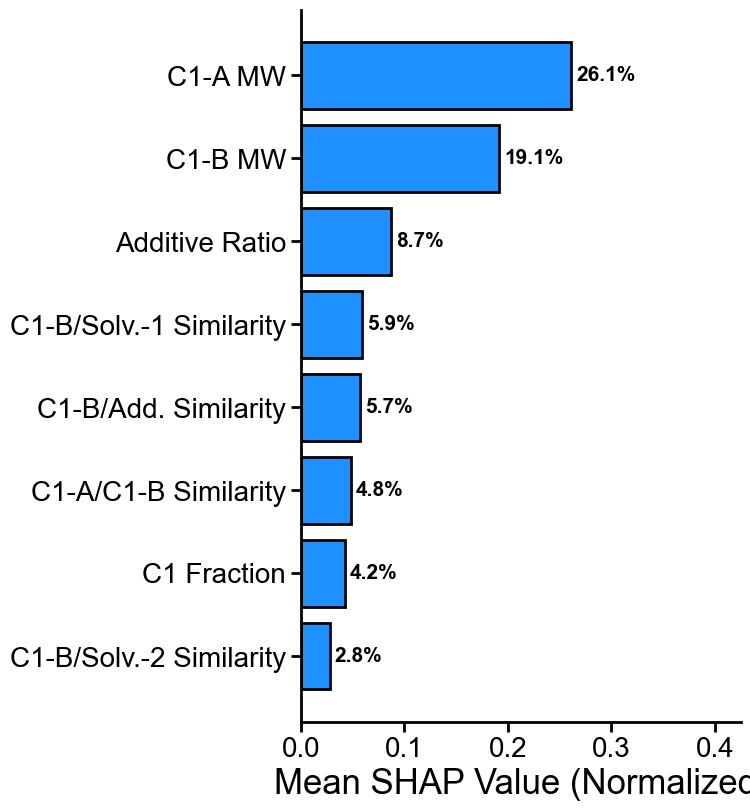

In [43]:
# Version to standardize plotting area
# Define the figure title
fig_title = 'shap_global.pdf'

# Plot
fig, ax = plt.subplots(figsize=(8, 8))
y_positions = np.arange(len(features_sorted))
ax.barh(y_positions, avg_shap_sorted, color='dodgerblue', edgecolor='black', linewidth=2)
ax.set_yticks(y_positions)
ax.set_yticklabels(features_sorted, fontsize=20)
ax.invert_yaxis()
ax.set_xlabel('Mean SHAP Value (Normalized)', fontsize=25)
ax.tick_params(axis='x', labelsize=20)
ax.xaxis.set_major_locator(MultipleLocator(0.1))
ax.set_xlim(0, 0.425)

# Add value labels next to each bar
for i, val in enumerate(avg_shap_sorted):
    ax.text(val + 0.005, i, f'{val:.1%}', va='center', fontweight='bold', fontsize=15)

# Clean styling
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
# plt.tight_layout()
plt.subplots_adjust(left=0.4, right=0.95, top=0.99, bottom=0.1)
# ax.set_facecolor('none')  # Sets the plotting area to transparent
# fig.patch.set_alpha(0.0)  # Ensures the figure background has 0 opacity
# plt.savefig(output_path + fig_title, format='pdf', transparent=True)
plt.savefig(output_path + fig_title, format='pdf', transparent=True)
plt.show()

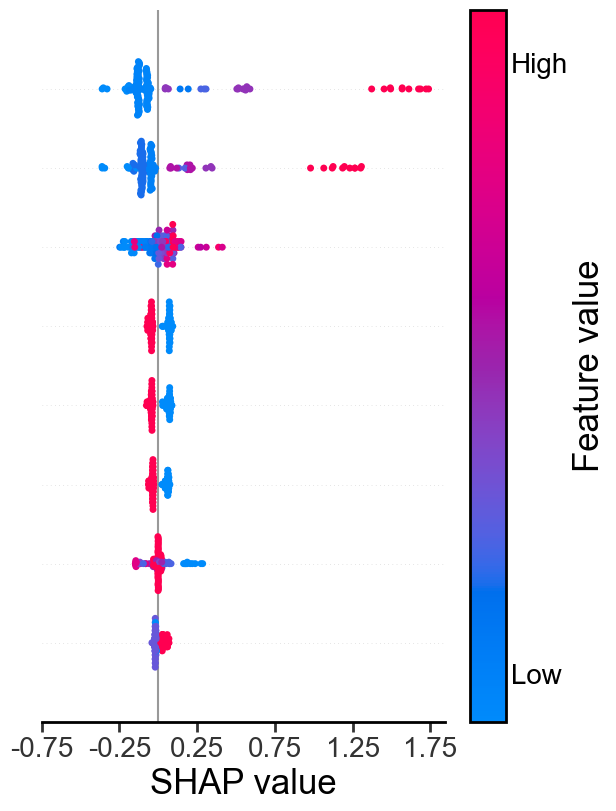

In [42]:
# Define figure title
fig_title = 'shap_local.pdf'

show_feature_names = False

# Automatically get feature names
if hasattr(X_train_scaled, 'columns'):
    feature_names = X_train_scaled.columns.tolist()
else:
    feature_names = [f'Feature {i+1}' for i in range(X_train_scaled.shape[1])]

normalizer = np.abs(shap_values).mean(axis=0).sum()
shap_values_normalized = shap_values / normalizer

# Create the SHAP summary plot
plt.figure(figsize=(6, 8))
shap.summary_plot(
    shap_values_normalized,
    X_test_scaled,
    feature_names=feature_names,
    max_display=8,
    show=False,
    color_bar=False,
    plot_size=None
)

# Remove feature names if toggle is off
if not show_feature_names:
    ax = plt.gca()
    ax.set_yticklabels([])
    ax.set_ylabel('')  # remove "Feature" label if SHAP adds it
    
# Add and customize the colorbar
cbar = plt.colorbar()
cbar.set_label('Feature value', fontsize=25, wrap=True)
cbar.ax.tick_params(labelsize=20)

# Customize the colorbar ticks to show 'high' and 'low'
cbar.set_ticks([-0.25, 4.25])
cbar.set_ticklabels(['Low', 'High'])
cbar.ax.tick_params(direction='out', length=0, width=0, grid_alpha=0.5)

# Set labels and ticks
plt.xlabel('SHAP value', fontsize=25)
plt.xticks(fontsize=20)
# ax.ticklabel_format(axis='x', style='sci', scilimits=(0, 0))
ax.xaxis.offsetText.set_fontsize(20)

# plt.tight_layout()
plt.subplots_adjust(left=0.06, right=0.9, top=0.99, bottom=0.1)

ax = plt.gca()
# Use plain formatting and turn off the offset
ax.ticklabel_format(useOffset=False, style='plain', axis='x')

# Re-apply the fontsize just to be sure
plt.xticks(fontsize=20)
# Generate ticks from the start to end in 0.25 steps
# Adding a small buffer to xmax ensures the final tick is included
# custom_ticks = np.arange(np.floor(xmin*4)/4, xmax + 0.01, 0.5)
custom_ticks = np.arange(-0.75, 1.76, 0.5)

ax.set_xticks(custom_ticks)
ax.set_xticklabels([f'{x:.2f}' for x in custom_ticks], fontsize=20)
# Save and show
# plt.savefig(output_path + fig_title, format='pdf', transparent=True)
plt.savefig(output_path + fig_title, format='pdf', transparent=True)
plt.show()

In [17]:
# --- Map each feature to its SHAP value and index ---
shap_feature_map = pd.DataFrame({
    'Index': range(len(features_r)),
    'Feature': features_r,
    'Avg_SHAP': avg_shap_per_feature
}).sort_values('Avg_SHAP', ascending=False)

print(shap_feature_map.to_string(index=False))

 Index                                      Feature  Avg_SHAP
    45                              comp1_blockA_MW  0.261056
    46                              comp1_blockB_MW  0.191497
    44                                    add_ratio  0.087345
    18            comp1_blockB_type_solv_1_likeness  0.059192
    16          comp1_blockB_type_add_type_likeness  0.056926
     0 comp1_blockA_type_comp1_blockB_type_likeness  0.048145
    42                                   comp1_frac  0.042418
    20            comp1_blockB_type_solv_2_likeness  0.027867
     5   comp1_blockA_type_comp2_blockB_type_exists  0.016529
    22 comp2_blockA_type_comp2_blockB_type_likeness  0.012530
    23   comp2_blockA_type_comp2_blockB_type_exists  0.012367
    30          comp2_blockB_type_add_type_likeness  0.011440
    32            comp2_blockB_type_solv_1_likeness  0.011047
    35              comp2_blockB_type_solv_2_exists  0.010774
    48                              comp2_blockB_MW  0.010647
    26  

In [129]:
import matplotlib.ticker as ticker

def plot_shap_dependence(shap_values, full_set, feature_names, target_feature,
                         interaction_feature, xscaler=None, output_path=None,
                         ylim=None, xlim=None, target_title=None, interaction_title=None,
                         xtick_interval=None, ytick_interval=None):
    # Inverse transform if scaler provided
    full_set_inv = xscaler.inverse_transform(full_set) if xscaler else full_set
    # Look up indices by feature name
    target_idx = feature_names.index(target_feature)
    interaction_idx = feature_names.index(interaction_feature) if interaction_feature else "auto"
    # Build subset: keep only target + interaction feature
    if interaction_feature:
        keep_idx = sorted(set([target_idx, interaction_idx]))
        shap_subset = shap_values[:, keep_idx]
        x_subset = full_set_inv[:, keep_idx]
        subset_names = [feature_names[i] for i in keep_idx]
        plot_feature = subset_names[keep_idx.index(target_idx)]
    else:
        shap_subset = shap_values
        x_subset = full_set_inv
        subset_names = feature_names
        plot_feature = target_feature
    # Use custom titles if provided, otherwise fall back to feature names
    x_label = target_title if target_title else target_feature
    y_label = f'SHAP value of {target_title if target_title else target_feature}'
    # Plot
    fig, ax = plt.subplots(figsize=(8, 8))
    shap.dependence_plot(
        plot_feature,
        shap_subset,
        x_subset,
        feature_names=subset_names,
        interaction_index=interaction_feature if interaction_feature else "auto",
        show=False,
        dot_size=100,
        ax=ax
    )
    if interaction_title:
        for ax_i in fig.axes:
            if ax_i != ax:
                ax_i.set_ylabel(interaction_title, fontsize=25)
                break
    ax_i.tick_params(labelsize=20)
    ax.set_xlabel(x_label, fontsize=25)
    ax.set_ylabel(y_label, fontsize=25, wrap=True)
    ax.tick_params(axis='both', labelsize=20)
    for collection in ax.collections:
        cmap = collection.get_cmap()
        norm = collection.norm
        data = collection.get_array()  # the values driving the colormap
        per_dot_colors = cmap(norm(data))  # RGBA array per dot
        collection.set_edgecolor(per_dot_colors)
        collection.set_alpha(0.85)
        collection.set_linewidth(1)
    
    # Apply matching alpha to the colorbar
    for ax_i in fig.axes:
        if ax_i != ax:  # colorbar axes
            # if ax_i.images:
            #     ax_i.images[0].set_alpha(0.5)
            # Also update the colorbar's mappable if accessible
            for im in ax_i.get_children():
                if hasattr(im, 'set_alpha'):
                    im.set_alpha(0.85)
            for spine in ax_i.spines.values():
                spine.set_visible(True)
                spine.set_alpha(1.0)
                # spine.set_linewidth(1.5)
                spine.set_edgecolor('black')
    if ylim:
        ax.set_ylim(ylim)
    if xlim:
        ax.set_xlim(xlim)
    # Set custom tick intervals after setting axis limits
    if xtick_interval:
        ax.xaxis.set_major_locator(ticker.MultipleLocator(xtick_interval))
    if ytick_interval:
        ax.yaxis.set_major_locator(ticker.MultipleLocator(ytick_interval))
    plt.tight_layout()
    if output_path:
        fig_title = f"{target_feature}_vs_{interaction_feature}".replace(" ", "_")
        fig.savefig(f"{output_path}{fig_title}.pdf", format='pdf')
        print(f"Saved to {output_path}{fig_title}.pdf")
    plt.close(fig)
    return fig

Saved to ./final_figs/gisaxs_domain_bayesian/shap/comp1_frac_vs_add_ratio.pdf


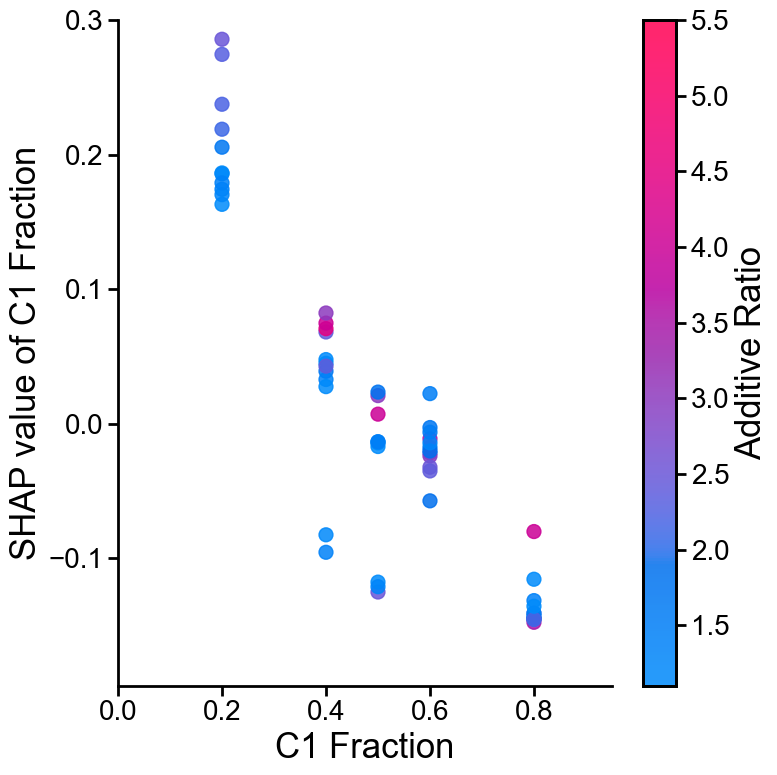

In [130]:
# Example: replicate your original 3 plots
plot_shap_dependence(shap_values_normalized, X_test_scaled, features_r,
                     target_feature='comp1_frac',
                     target_title='C1 Fraction',
                     interaction_feature='add_ratio',
                     interaction_title='Additive Ratio',
                     xscaler=scaler, output_path=output_path, ylim=(-0.195, 0.3), xlim=(0, 0.95),
                     xtick_interval=0.2,
                     ytick_interval=0.1)